<a href="https://colab.research.google.com/github/Riz2693/Eksperimen-TensorFlow/blob/main/Transformer%20BERT%20From%20Scratch%20With%20TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow==2.19.0 tensorflow_datasets==4.9.9 transformers==4.55.2

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import transformers
from transformers import AutoTokenizer

In [3]:
def positional_encoding(length, depth):
  # Membagi dua dimensi untuk sin & cos
  depth = depth / 2
  # print("Depth", depth)

  # Membuat array posisi dengan shape (length, 1)
  # [:, np.newaxis] untuk determinan matriks (konversi baris ke kolom)
  # Contoh: Shape matriks awalnya (4) [0,1,2,3] menjadi (4, 1)
  # [0]
  # [1]
  # [2]
  # [3]
  positions = np.arange(length)[:, np.newaxis]
  # print("Position", positions)

  # Membuat array dimensi dengan shape (1, depth)
  # hasil dari array berupa array baris [0,1] dengan shape (2) menjadi array baris 1D dengan shape (1,2) atau [[0,1]]
  # misal: depths = i dan depth = d/2
  # maka: depths/depth = i / d/2 atau 2*i / d
  depths = np.arange(depth)[np.newaxis, :] / depth
  # print("Depths", depths)

  # Perhitungan sudut yang akan digunakan dalam sinus & cosinus
  angle_rates = 1 / (10000**depths)
  # print("Angle rates", angle_rates)
  angle_rads = positions * angle_rates
  # print("Angle rads", angle_rads)

  # Atau bisa menggunakan
  # angle_rads = positions / (10000**depths)

  # Menghitung nilai sinus dan cosinus pada setiap posisi
  pos_encoding = np.concatenate(
      [np.sin(angle_rads), np.cos(angle_rads)],
      axis=-1)

  # Mengonversi hasil encoding menjadi Float32 dengan shape (1, length, depth)
  return tf.cast(pos_encoding, dtype=tf.float32)[tf.newaxis, ...]

In [4]:
class PositionalEmbedding(layers.Layer):
  def __init__(self, vocab_size, d_model, max_length=2048):
    super().__init__()
    self.d_model = d_model
    self.embedding = layers.Embedding(vocab_size, d_model, mask_zero=True)
    self.pos_encoding = positional_encoding(max_length, d_model)

  # Fungsi untuk meneruskan masking (hanya jika ada decoder)
  def compute_mask(self, *args, **kwargs):
    return self.embedding.compute_mask(*args, **kwargs)

  def call(self, x):
    # Mengambil panjang "seq_length" x (input)
    length = tf.shape(x)[1]
    # Menjalankan Embedding pada x, shape menjadi (batch_size, seq_length, d_model)
    x = self.embedding(x)
    # Skalakan embedding
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
     # Tambahkan positional encoding ke embedding
    x = x + self.pos_encoding[:, :length, :]

    return x

In [5]:
class Multi_Head_Attention(layers.Layer):
  def __init__(self, d_model, num_heads, **kwargs):
    super(Multi_Head_Attention, self).__init__(**kwargs)

    # Inisialisasi jumlah head yang diinginkan
    self.num_heads = num_heads

    # Inisialisasi dimensi model
    self.d_model = d_model

    # Memastikan dimensi model habis dibagi dengan jumlah head
    assert d_model % self.num_heads == 0

    # Inisialisasi dimensi untuk setiap head
    self.depth = d_model // self.num_heads

    # Inisialisasi tiga layer untuk Query, Key da Value
    self.wq = layers.Dense(d_model)
    self.wk = layers.Dense(d_model)
    self.wv = layers.Dense(d_model)

    # Layer dense akhir untuk output setelah menggabungkan semua head
    self.dense = layers.Dense(d_model)

  # Fungsi untuk mengambil input x dan membaginya ke dalam beberapa head
  def split_heads(self, x, batch_size):
    x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
    # Atau bisa menggunakan
    # seq_len = tf.shape(x)[1]
    # x = tf.reshape(x, (batch_size, seq_len, self.num_heads, self.depth))
    return tf.transpose(x, perm=[0, 2, 1, 3])

  # Fungsi perhitungan Scaled Dot Product
  def scaled_dot_product_attention(self, q, k, v, mask):
    matmul_qk = tf.matmul(q, k, transpose_b=True)

    # Contoh shape dari k: (1, 2, 4, 2)
    # Maka, nilai dk (depth_per_head) atau (dimensi per kepala): 2.0
    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

    if mask is not None:
      scaled_attention_logits += (mask * -1e9)

    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
    output = tf.matmul(attention_weights, v)

    return output, attention_weights

  def call(self, v_input, k_input, q_input, mask):
    batch_size = tf.shape(q_input)[0]

    # Lakukan proyeksi linear menggunakan layer Dense yang telah didefinisikan
    q = self.wq(q_input)
    k = self.wk(k_input)
    v = self.wv(v_input)

    # Bagi menjadi beberapa head
    q = self.split_heads(q, batch_size)
    k = self.split_heads(k, batch_size)
    v = self.split_heads(v, batch_size)

    # Lakukan Scaled Dot Product untuk setiap head
    # Output: token yang diperhatikan dan bobotnya
    scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)

    # Menukar posisi num_heads dengan seq_len_q (panjang Query)
    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

    # Menggabungkan hasil dari seluruh head menjadi satu tensor
    # Tujuan tensor: (batch_size, seq_len_q, d_model), dimana d_model = depth * num_heads
    concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))

    # Layer dense akhir untuk menghasilkan output
    output = self.dense(concat_attention)

    return output, attention_weights

In [6]:
class Feed_Forward(layers.Layer):
  def __init__(self, d_model, dff):
    super().__init__()
    # Inisialisasi layer dense pertama dengan aktivasi ReLu
    self.dense1 = layers.Dense(dff, activation='relu')
    # Inisialisasi layer dense kedua (output)
    self.dense2 = layers.Dense(d_model)

  def call(self, x):
    x = self.dense1(x)
    x = self.dense2(x)

    return x

In [7]:
class Encoder_layer(layers.Layer):
  def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
    super().__init__()

    # Inisialisasi mekanisme Multi-Head Attention
    self.mha = Multi_Head_Attention(d_model=d_model, num_heads=num_heads)

    # Inisialisasi Feed Forward
    self.ffn = Feed_Forward(d_model=d_model, dff=dff)

    # Inisialiasi layer normalization untuk Multi Head Attention
    self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)

    # Inisialisasi layer normalization untuk Feed Forward
    self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

    # Dropout untuk Multi Head Attention
    self.dropout1 = layers.Dropout(dropout_rate)

    # Dropout untuk Feed Forward
    self.dropout2 = layers.Dropout(dropout_rate)

  def call(self, x, mask, training):
    # Multi Head Attention
    # Query, Key dan Value berasal dari input yang sama (x)
    attn_output, _ = self.mha(x, x, x, mask=mask)
    # Terapkan dropout pada output attention
    attn_output = self.dropout1(attn_output, training=training)
    # Residual connection (x + attn_output) dan Layer Normalization
    output_mha = self.layernorm1(x + attn_output)

    # Feed Forward
    ffn_output = self.ffn(output_mha)
    # Terapkan dropout pada output FFN
    ffn_output = self.dropout2(ffn_output, training=training)
    # Residual connection (output_mha + ffn_output) dan Layer Normalization
    output = self.layernorm2(output_mha + ffn_output)

    return output

In [8]:
class Encoder(layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads, dff, vocab_size, max_length=2048, dropout_rate=0.1):
    super().__init__()
    # Inisialisai dimensi model
    self.d_model = d_model
    # Inisialiasi jumlah EncoderLayer
    self.num_layers = num_layers
    # Fungsi Positional_Embedding yang berisi Token Embedding dan Positional Encoding
    self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size,
                                             d_model=d_model, max_length=max_length)

    # Inisialisasi residual layer dari fungsi Encoder_Layer
    self.enc_layers = [Encoder_layer(d_model=d_model,
                                    num_heads=num_heads,
                                    dff=dff,
                                    dropout_rate=dropout_rate)
    for _ in range(num_layers)]

    # Inisialisasi layer dropout
    self.dropout = layers.Dropout(dropout_rate)

  def create_padding_mask(self, seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    # Tambahkan dimensi ekstra agar sesuai dengan format attention_mask
    # (batch_size, 1, 1, seq_len)
    return seq[:, tf.newaxis, tf.newaxis, :]

  def call(self, x, training):
    padding_mask = self.create_padding_mask(x)

    x = self.pos_embedding(x)

    x = self.dropout(x, training=training)

    for i in range(self.num_layers):
      x = self.enc_layers[i](x, mask=padding_mask, training=training)

    # Atau bisa menggunakan
    # for layer in self.enc_layer:
    #   x = layer(x, mask=padding_mask, training=training)

    return x

In [9]:
class TransformerClassifier(tf.keras.Model):
  def __init__(self, *, num_layers, d_model, num_heads, dff, vocab_size, num_classes, max_length=2048, dropout_rate=0.1):
    super().__init__()
    self.encoder = Encoder(num_layers=num_layers,
                           d_model=d_model,
                           num_heads=num_heads,
                           dff=dff,
                           vocab_size=vocab_size,
                           max_length=max_length,
                           dropout_rate=dropout_rate)

    self.pooling = layers.GlobalAveragePooling1D()

    self.classifier  = layers.Dense(num_classes, activation='softmax' if num_classes > 2 else 'sigmoid')

  def call(self, x, training):
    x = self.encoder(x, training=training)
    x = self.pooling(x)
    x = self.classifier(x)
    return x

In [10]:
# Inisialisasi Hyperparameter
MAX_LENGTH = 256
BUFFER_SIZE = 20000
BATCH_SIZE = 64
MODEL_NAME = 'bert-base-uncased'

NUM_LAYERS = 2
D_MODEL = 128
NUM_HEADS = 4
DFF = 256
DROPOUT_RATE = 0.1
NUM_CLASSES = 1

In [11]:
(ds_train, ds_test), ds_info = tfds.load('imdb_reviews',
                                         split=['train', 'test'],
                                         shuffle_files=True,
                                         as_supervised=True,
                                         with_info=True)
print("Dataset IMDB berhasil dimuat")

Dataset IMDB berhasil dimuat


In [12]:
tokenizer_hf = AutoTokenizer.from_pretrained(MODEL_NAME)
VOCAB_SIZE_ACTUAL = tokenizer_hf.vocab_size

print(f"Tokenizer berhasil dimuat. Ukuran vocabulary: {VOCAB_SIZE_ACTUAL}")

# Pastikan pad_token_id adalah 0, karena model kita membuat mask berdasarkan itu
print(f"Padding token ID: {tokenizer_hf.pad_token_id}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer berhasil dimuat. Ukuran vocabulary: 30522
Padding token ID: 0


In [13]:
def hf_encode_py(text_tensor_py):
  text_str = text_tensor_py.numpy().decode('utf-8')
  encoded = tokenizer_hf(
      text_str,
      padding='max_length',
      truncation=True,
      max_length=MAX_LENGTH,
      return_tensors='tf'
  )
  input_ids_sliced = tf.squeeze(encoded['input_ids'], axis=0)

  return input_ids_sliced

In [14]:
@tf.function
def encode_pad(text_tensor, label_tensor):
  input_ids = tf.py_function(func=hf_encode_py,
                            inp=[text_tensor],
                            Tout=tf.int32)
  input_ids.set_shape([MAX_LENGTH])
  input_ids_int64 = tf.cast(input_ids, tf.int64)

  return input_ids_int64, label_tensor

In [15]:
ds_train_processed = ds_train.map(encode_pad,
                                   num_parallel_calls=tf.data.AUTOTUNE)
ds_train_processed = ds_train_processed.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

ds_test_processed = ds_test.map(encode_pad, num_parallel_calls=tf.data.AUTOTUNE)
ds_test_processed = ds_test_processed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [16]:
# Inisialisasi Model Transformer kita
transformer_classifier_model = TransformerClassifier(
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dff=DFF,
    vocab_size=VOCAB_SIZE_ACTUAL,
    num_classes=NUM_CLASSES,
    max_length=MAX_LENGTH,
    dropout_rate=DROPOUT_RATE
)

# Inisialisasi loss function dan optimizers
loss_function = tf.keras.losses.BinaryCrossentropy(from_logits=False)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# Compile model
transformer_classifier_model.compile(loss=loss_function,
                                     optimizer=optimizer,
                                     metrics=['accuracy'])

# Bangun model dengan data dummy
dummy_input_val = tf.minimum(tf.cast(VOCAB_SIZE_ACTUAL -1, tf.int64) , 1000)

dummy_input = tf.random.uniform((BATCH_SIZE, MAX_LENGTH), maxval=dummy_input_val, dtype=tf.int64)

_ = transformer_classifier_model(dummy_input, training=False)

# Melihat detail ringkasan dari arsitektur model Transformer
transformer_classifier_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi__head__attention' (of type Multi_Head_Attention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer' (of type Encoder_layer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi__head__attention_1' (of type Multi_Head_Attention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the

Model: "transformer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │     4,171,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (64, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,171,905 (15.91 MB)

 Trainable params: 4,171,905 (15.91 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = transformer_classifier_model.fit(ds_train_processed,
                                         validation_data=ds_test_processed,
                                         epochs=3)

Epoch 1/3


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


391/391 ━━━━━━━━━━━━━━━━━━━━ 171s 222ms/step - accuracy: 0.7339 - loss: 0.5058 - val_accuracy: 0.8298 - val_loss: 0.3715
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 97s 167ms/step - accuracy: 0.8857 - loss: 0.2772 - val_accuracy: 0.8566 - val_loss: 0.3301
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 137s 260ms/step - accuracy: 0.9185 - loss: 0.2103 - val_accuracy: 0.8529 - val_loss: 0.3593


In [18]:
loss, accuracy = transformer_classifier_model.evaluate(ds_test_processed)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.8526 - loss: 0.3609

Test Loss: 0.3609
Test Accuracy: 0.8526


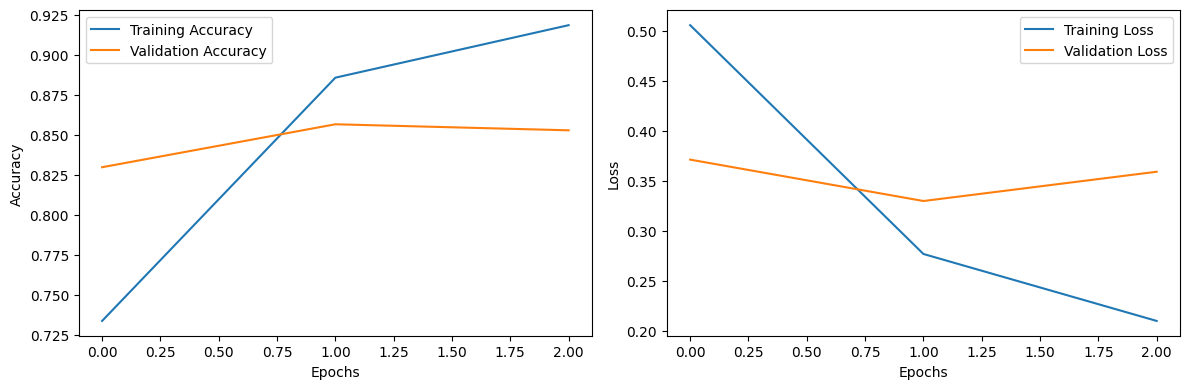

In [20]:
def plot_history(history_data):
  plt.figure(figsize=(12, 4))

  plt.subplot(1,2,1)
  plt.plot(history_data.history['accuracy'], label='Training Accuracy')
  plt.plot(history_data.history['val_accuracy'], label='Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(history_data.history['loss'], label='Training Loss')
  plt.plot(history_data.history['val_loss'], label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  plt.tight_layout()
  plt.show()

plot_history(history)

In [27]:
def predict_sentiment(text, hf_tokenizer_global, max_len_local):
    # Inisialisasi tokenizer
    encoded = hf_tokenizer_global(
        text,
        padding='max_length',
        truncation=True,
        max_length=max_len_local,
        return_tensors='tf'
    )

    input_ids = encoded['input_ids']
    batched_input = tf.cast(input_ids, tf.int64)

    # Prediksi
    prediction = transformer_classifier_model.predict(batched_input,verbose=0)
    sentiment_score = prediction[0][0]
    sentiment = "Positif" if sentiment_score > 0.5 else "Negatif"

    return sentiment, sentiment_score

In [28]:
sample_texts = [
    "This movie was absolutely fantastic! The acting was superb and the plot was thrilling.",
    "I hated this film. It was boring and the storyline was predictable.",
    "An incredible masterpiece, a must-watch for everyone!",
    "What a waste of time, I would not recommend this to anyone."
]

for text in sample_texts:
  sentiment, sentiment_score = predict_sentiment(text, tokenizer_hf, MAX_LENGTH)
  print(f"Teks: \"{text}\"")
  print(f"Prediksi: {sentiment} (Skor: {sentiment_score:.4f})\n")

Teks: "This movie was absolutely fantastic! The acting was superb and the plot was thrilling."
Prediksi: Positif (Skor: 0.9946)

Teks: "I hated this film. It was boring and the storyline was predictable."
Prediksi: Negatif (Skor: 0.0004)

Teks: "An incredible masterpiece, a must-watch for everyone!"
Prediksi: Positif (Skor: 0.9998)

Teks: "What a waste of time, I would not recommend this to anyone."
Prediksi: Negatif (Skor: 0.0022)

